In [5]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# EDA

In [6]:
data = []
with open('cian_offers.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

data = pd.DataFrame(data)
data.drop(['id'], axis=1, inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29129 entries, 0 to 29128
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              29129 non-null  int64  
 1   description        29129 non-null  object 
 2   rooms              28215 non-null  float64
 3   area_total         29129 non-null  float64
 4   area_living        22194 non-null  float64
 5   area_kitchen       24217 non-null  float64
 6   floor              29129 non-null  int64  
 7   floors_total       29129 non-null  int64  
 8   construction_year  25632 non-null  float64
 9   address            29129 non-null  object 
 10  district           29129 non-null  object 
 11  metros             29082 non-null  object 
 12  flat_type          29129 non-null  object 
 13  ceiling_height     23486 non-null  float64
 14  renovation_type    17863 non-null  object 
 15  parking            20207 non-null  object 
 16  accident_rate      163

In [8]:
data.describe()

,price,rooms,area_total,area_living,area_kitchen,floor,floors_total,construction_year,ceiling_height,entrances
count,2.912900e+04,28215.000000,29129.000000,22194.000000,24217.000000,29129.000000,29129.000000,25632.000000,23486.000000,13585.000000
mean,4.546217e+07,2.127237,69.622515,38.638749,13.540695,10.941914,21.081603,2004.587274,3.014419,4.748473
std,6.305310e+07,1.184976,47.699342,28.953039,8.633225,10.779314,15.457210,31.432149,0.771079,24.391175
min,9.500000e+05,0.000000,0.000000,1.000000,0.600000,1.000000,1.000000,1785.000000,0.000000,1.000000
25%,1.802372e+07,1.000000,40.900000,20.000000,8.000000,4.000000,9.000000,1984.000000,2.700000,2.000000
50%,2.732812e+07,2.000000,60.000000,32.100000,10.700000,7.000000,17.000000,2022.000000,3.000000,4.000000
75%,4.850000e+07,3.000000,84.000000,47.000000,17.800000,15.000000,27.000000,2026.000000,3.100000,6.000000
max,2.833614e+09,5.000000,952.000000,842.000000,117.000000,84.000000,97.000000,2031.000000,46.000000,2024.000000


In [9]:
print(f"Дубликатов: {data.drop(['metros', 'photo_keys'], axis=1).duplicated().sum()}")

Дубликатов: 85


In [10]:
ind = data.drop(['metros', 'photo_keys'], axis=1).drop_duplicates().index
df = data.iloc[ind]

print(f"Дубликатов: {df.drop(['metros', 'photo_keys'], axis=1).duplicated().sum()}")

Дубликатов: 0


In [11]:
missing = df.isnull().sum() / len(df) * 100
print(missing[missing > 0].sort_values(ascending=False))

entrances            53.418951
accident_rate        43.833494
heating              43.833494
renovation_type      38.644815
parking              30.574301
area_living          23.788046
elevators            23.412753
bathroom             20.699628
ceiling_height       19.356838
house_type           18.795620
area_kitchen         16.839967
construction_year    11.985264
rooms                 3.140063
metros                0.161823
dtype: float64


## Анализ target

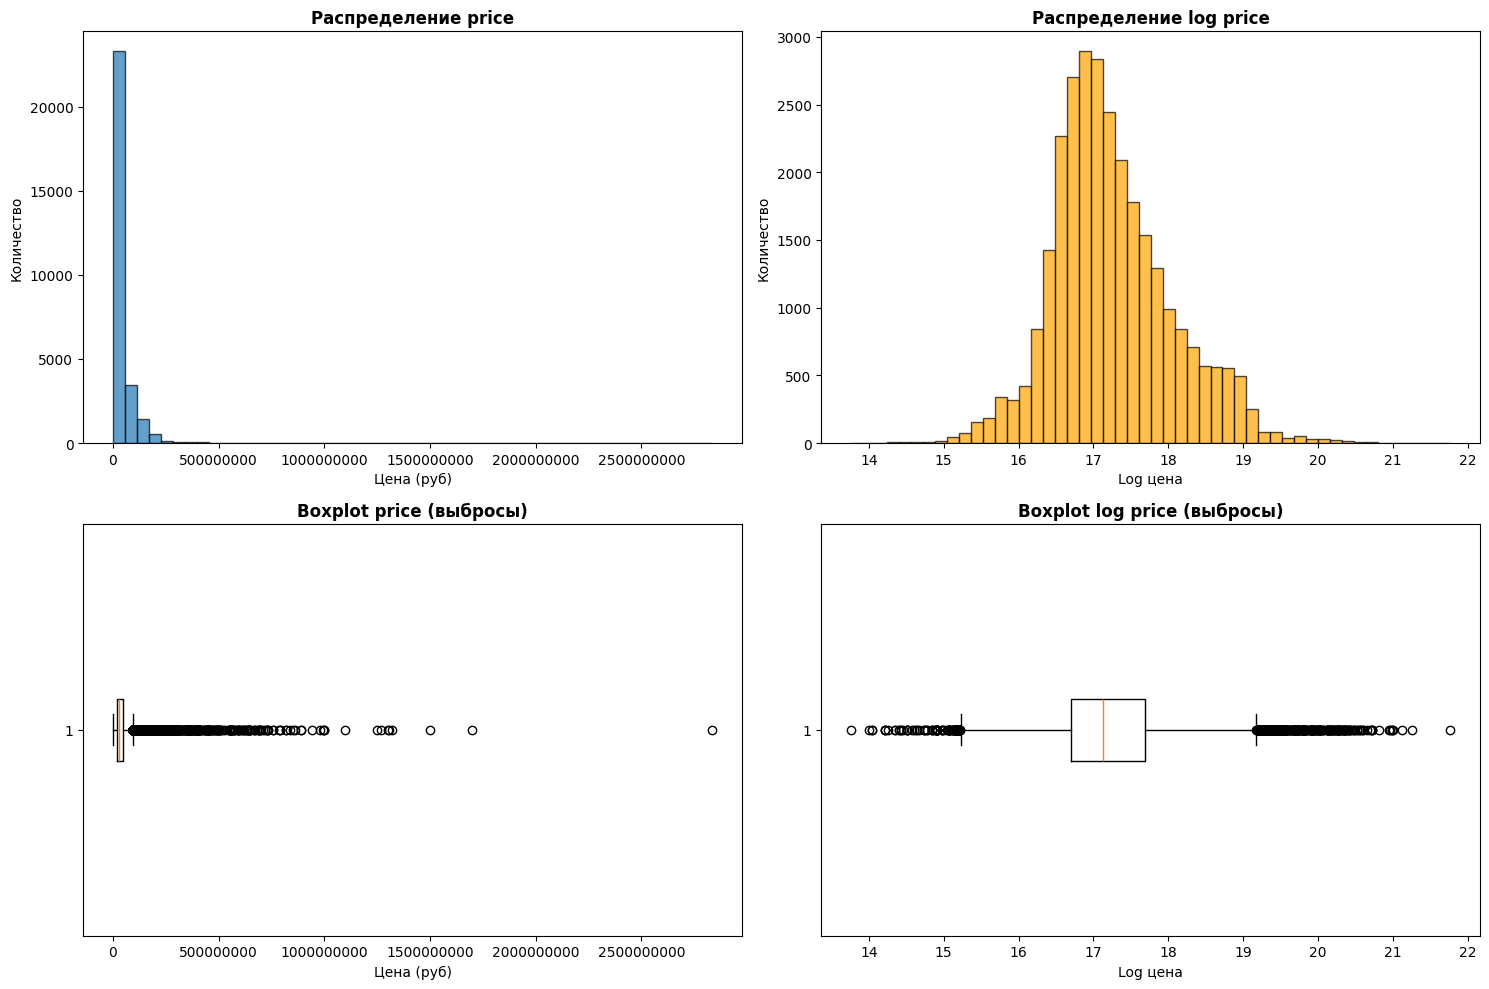

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Распределение цены
axes[0, 0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение price', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Цена (руб)')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Логарифм цены
axes[0, 1].hist(np.log1p(df['price']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Распределение log price', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Log цена')
axes[0, 1].set_ylabel('Количество')

# Boxplot для выбросов
axes[1, 0].boxplot(df['price'], vert=False)
axes[1, 0].set_title('Boxplot price (выбросы)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Цена (руб)')
axes[1, 0].ticklabel_format(style='plain', axis='x')

axes[1, 1].boxplot(np.log1p(df['price']), vert=False)
axes[1, 1].set_title('Boxplot log price (выбросы)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Log цена')
axes[1, 1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

## Анализ числовых признаков

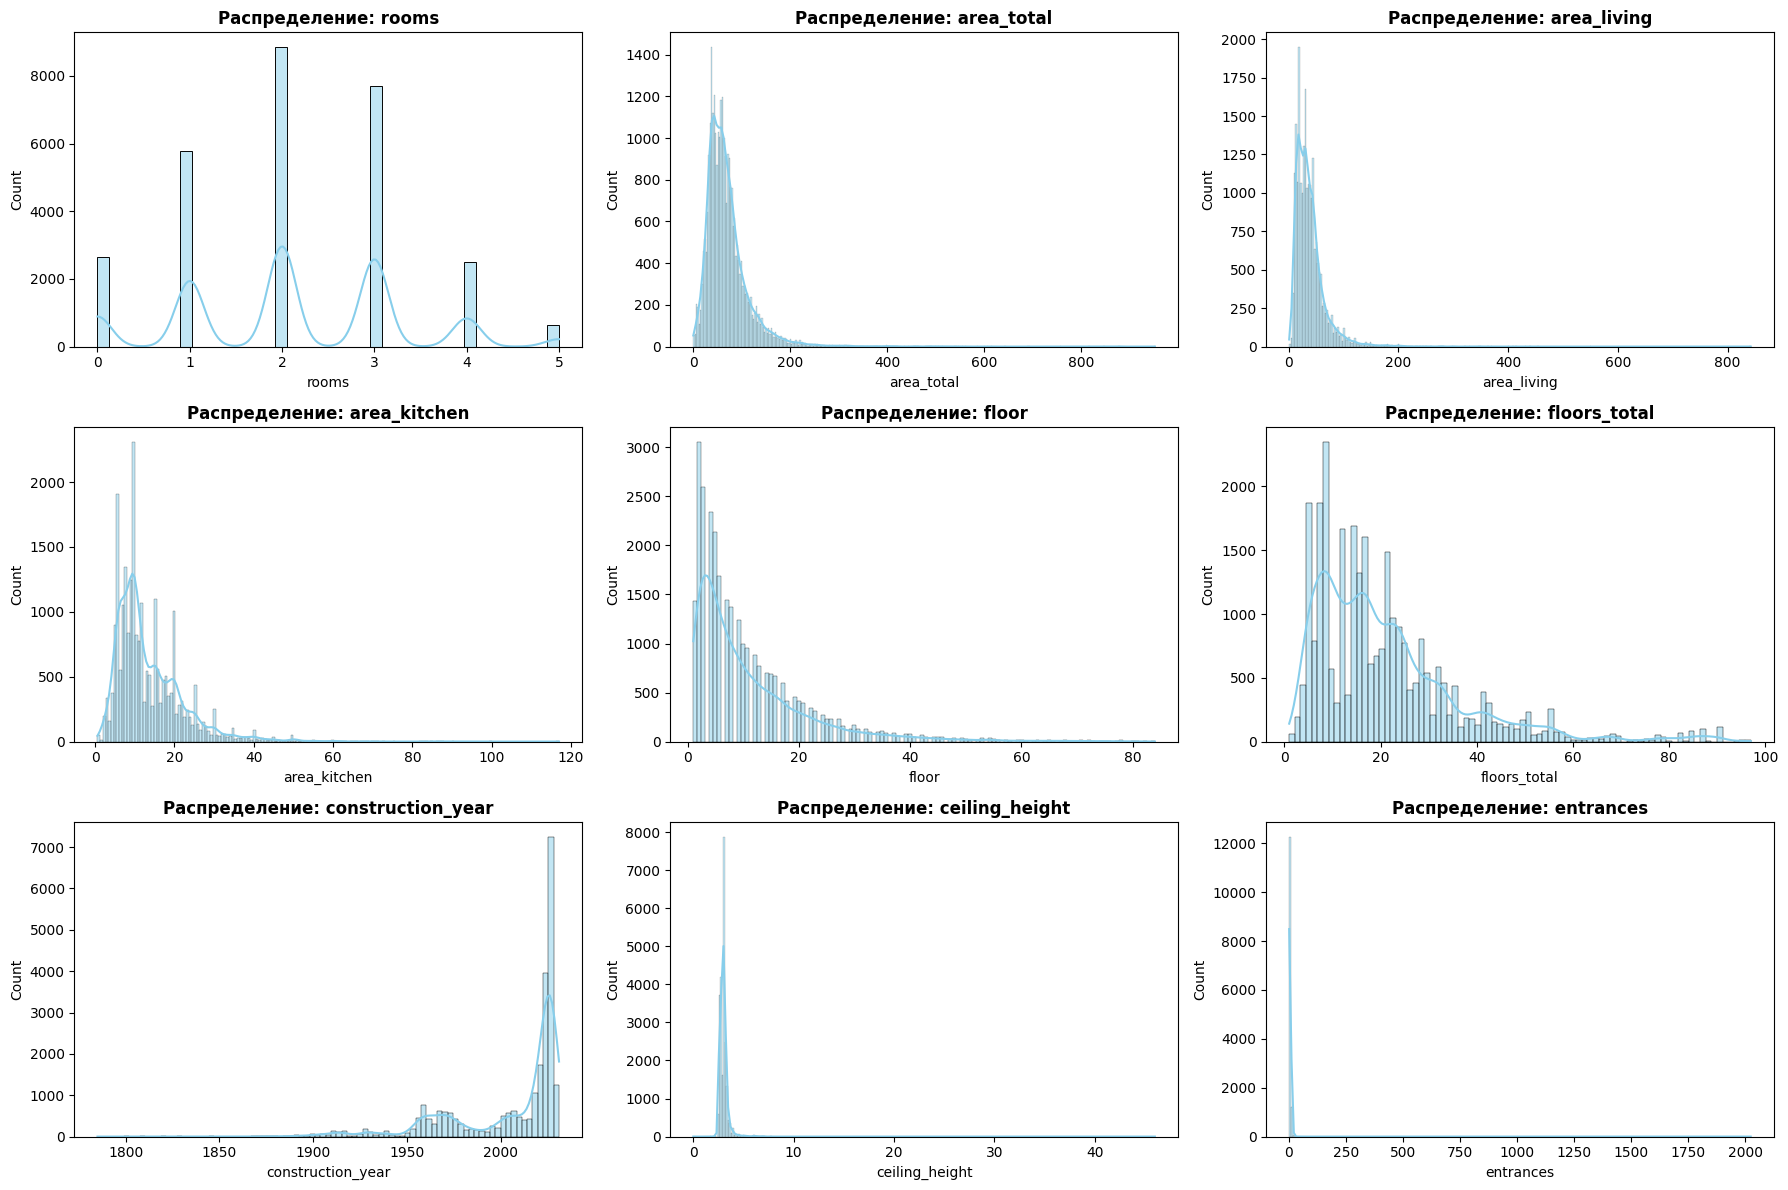

In [13]:
num_features = ['rooms', 'area_total', 'area_living', 'area_kitchen',
                'floor', 'floors_total', 'construction_year', 'ceiling_height', 'entrances']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    if feature in df.columns:
        sns.histplot(data=df, x=feature, kde=True, ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(f'Распределение: {feature}', fontweight='bold')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

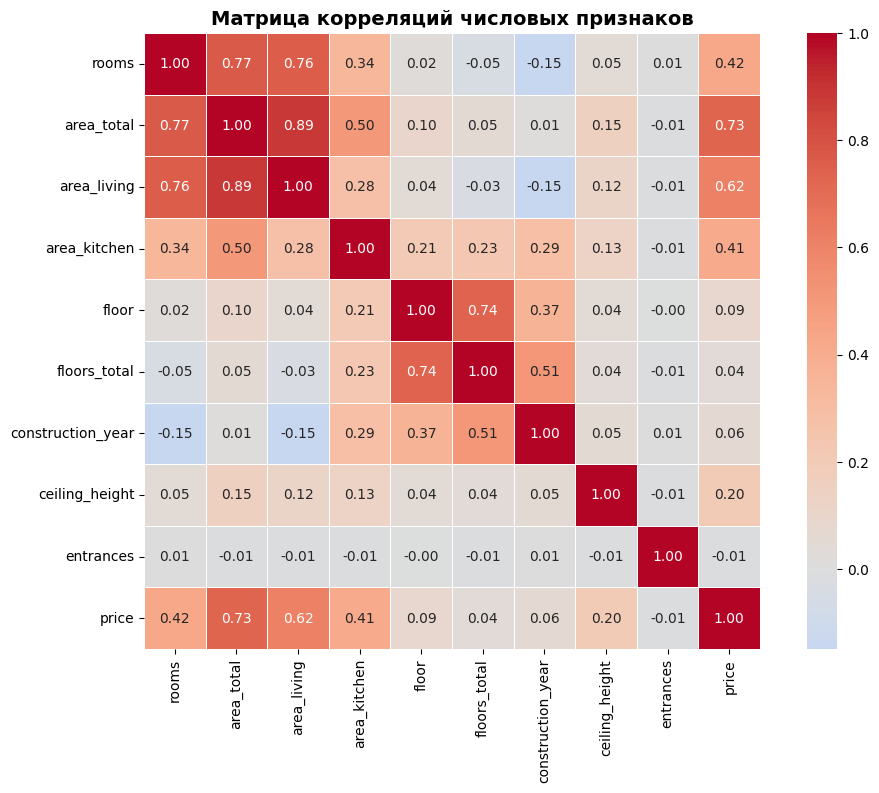

In [14]:
correlations = df[['price'] + num_features].corr()['price'].drop('price').sort_values(ascending=False)

plt.figure(figsize=(12, 8))
corr_matrix = df[num_features + ['price']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Матрица корреляций числовых признаков', fontsize=14, fontweight='bold')
plt.show()

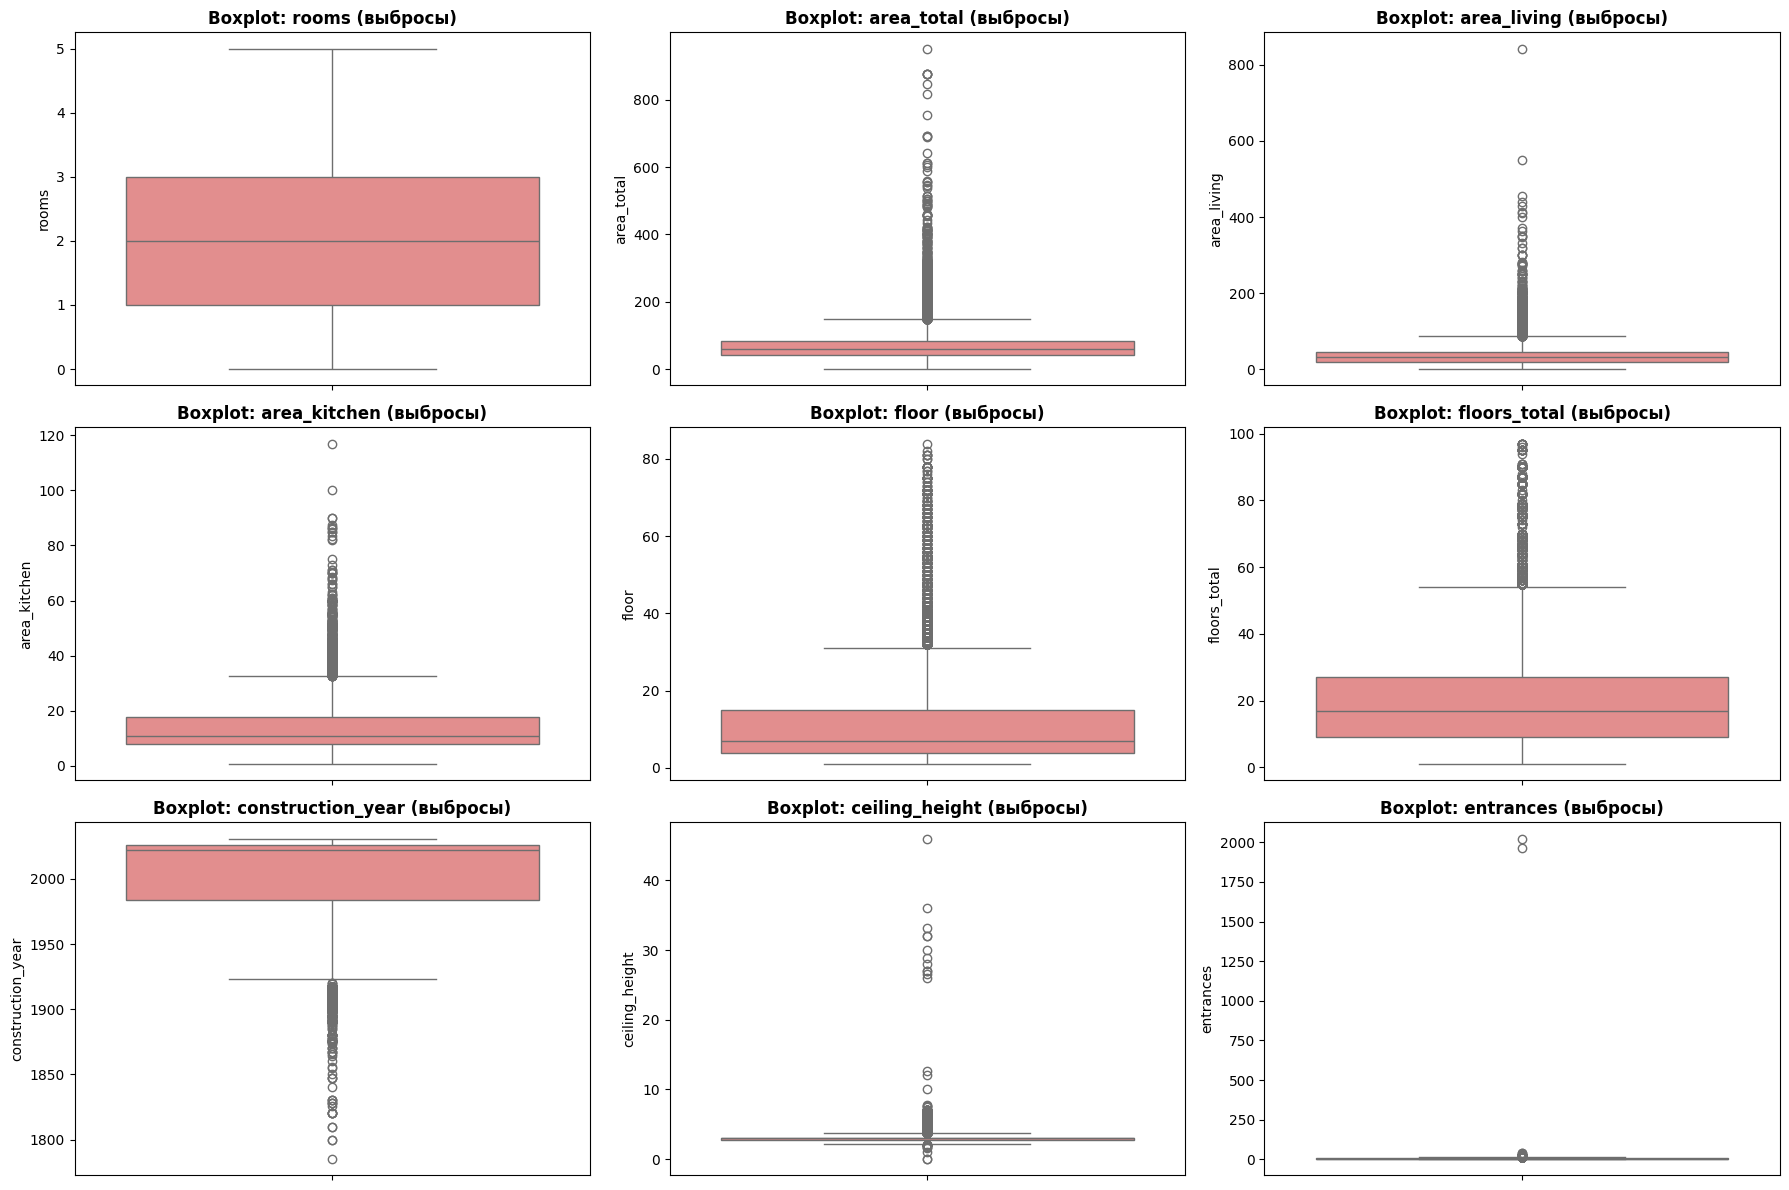

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    if feature in df.columns:
        sns.boxplot(y=df[feature], ax=axes[i], color='lightcoral')
        axes[i].set_title(f'Boxplot: {feature} (выбросы)', fontweight='bold')
        axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

## Анализ категориальных признаков

In [16]:
cat_features = ['district', 'flat_type', 'renovation_type', 'parking',
               'accident_rate', 'elevators', 'heating', 'bathroom', 'house_type']

print("Количество уникальных значений в категориальных признаках:")
df[cat_features].nunique()

Количество уникальных значений в категориальных признаках:


district            34
flat_type            6
renovation_type      4
parking              5
accident_rate        1
elevators          125
heating              7
bathroom            39
house_type           9
dtype: int64

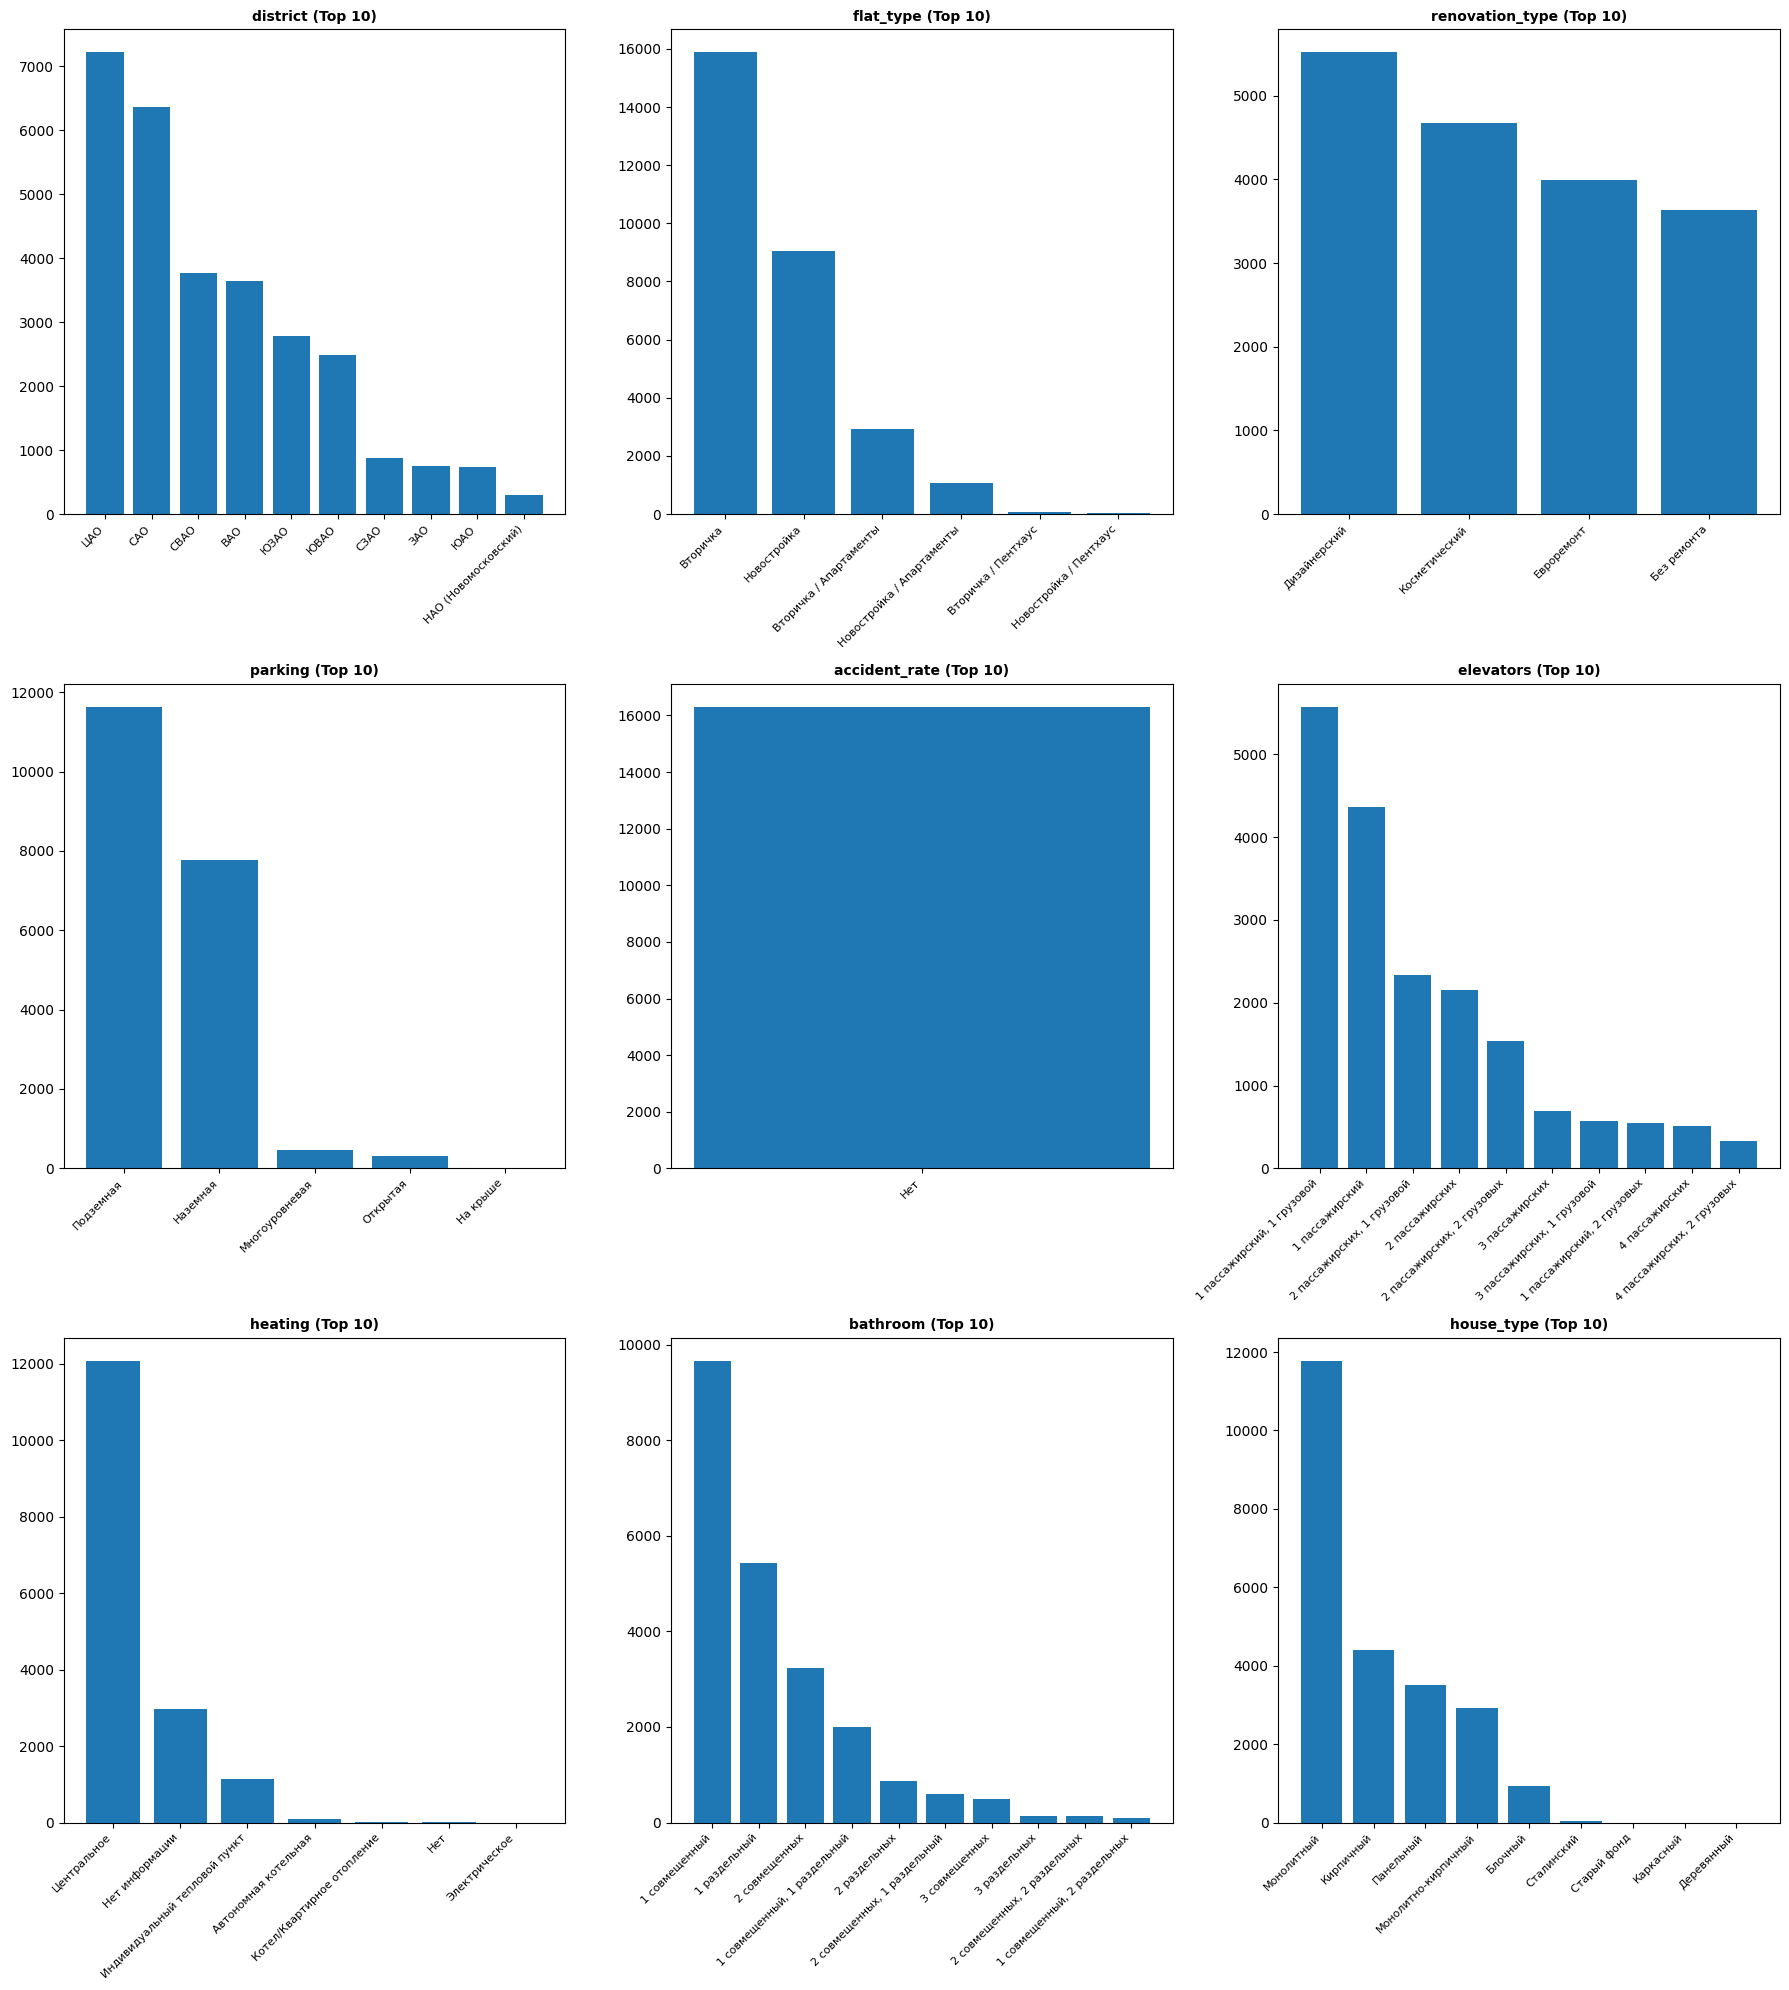

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if i < len(axes):
        value_counts = df[col].value_counts()
        if len(value_counts) > 10:
            value_counts = value_counts.head(10)

        axes[i].bar(range(len(value_counts)), value_counts.values)
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[i].set_title(f'{col} (Top 10)', fontweight='bold', fontsize=10)
        axes[i].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

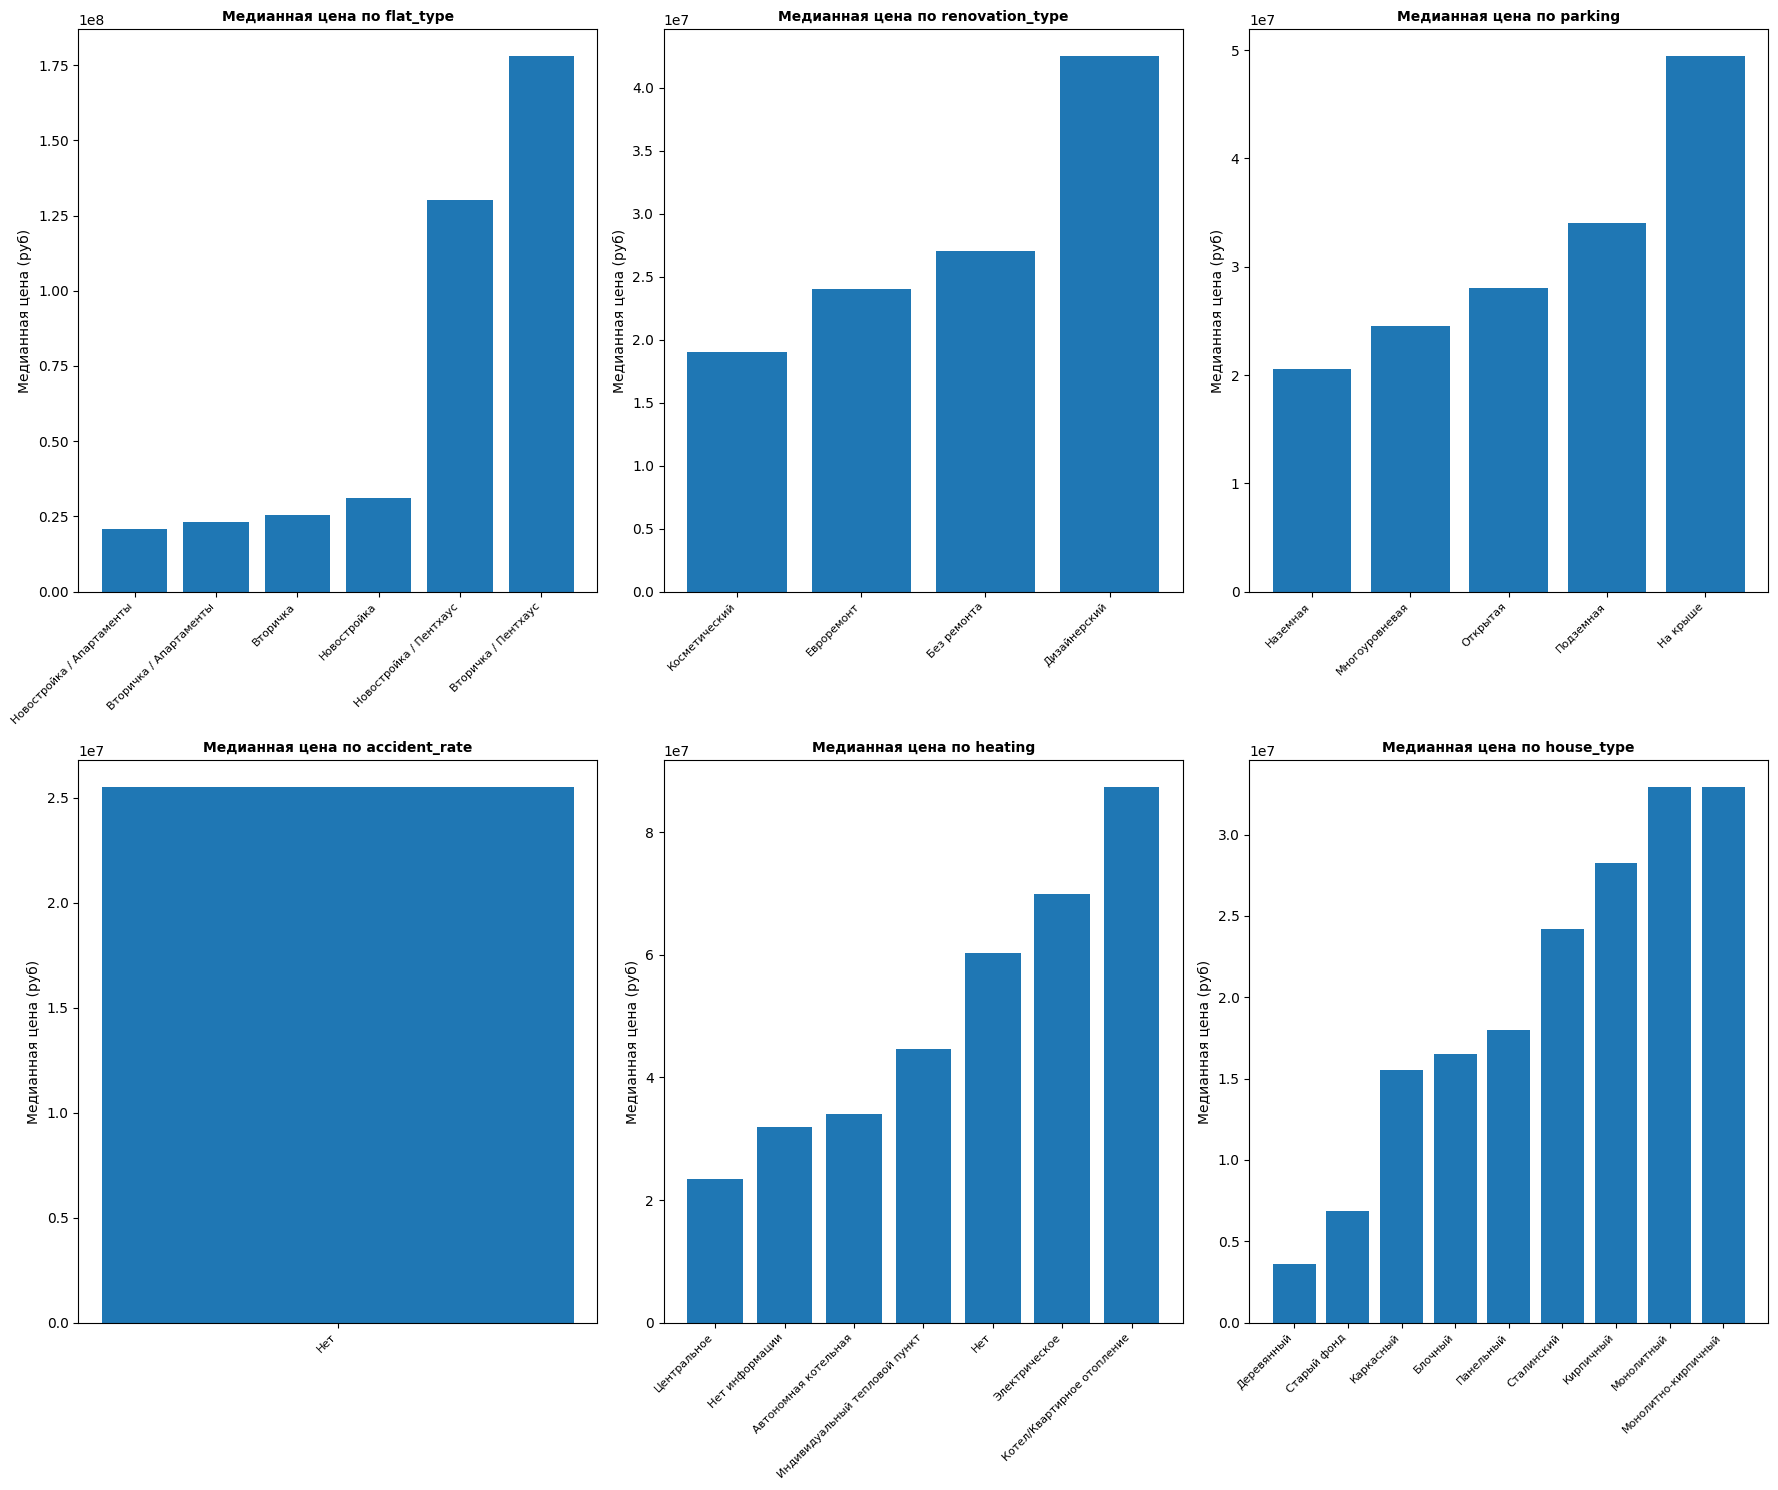

In [18]:
# Aнализ связи категориальных признаков с целевой переменной
# Для признаков с небольшим количеством категорий
fig, axes = plt.subplots(2, 3, figsize=(18, 15))
axes = axes.flatten()

small_cat_features = [col for col in cat_features if df[col].nunique() <= 10]

for i, col in enumerate(small_cat_features):
    if i < len(axes):
        grouped = df.groupby(col)['price'].median().sort_values()

        axes[i].bar(range(len(grouped)), grouped.values)
        axes[i].set_xticks(range(len(grouped)))
        axes[i].set_xticklabels(grouped.index, rotation=45, ha='right')
        axes[i].set_title(f'Медианная цена по {col}', fontweight='bold', fontsize=10)
        axes[i].tick_params(axis='x', labelsize=8)
        axes[i].set_ylabel('Медианная цена (руб)')

plt.tight_layout()
plt.show()

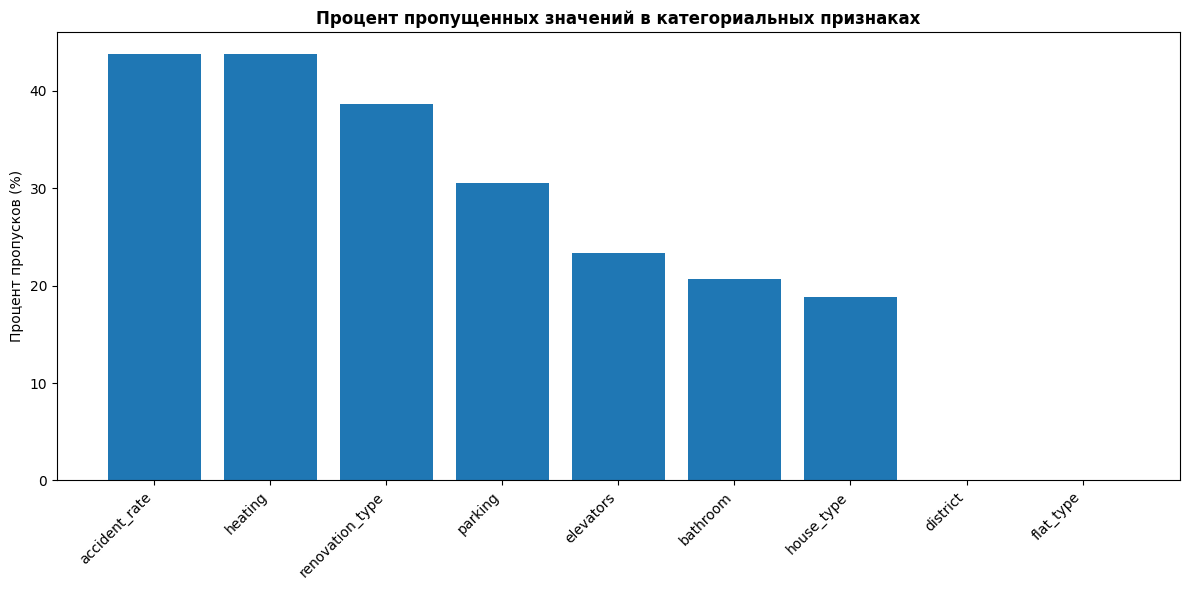

Процент пропущенных значений:
accident_rate      43.833494
heating            43.833494
renovation_type    38.644815
parking            30.574301
elevators          23.412753
bathroom           20.699628
house_type         18.795620
district            0.000000
flat_type           0.000000
dtype: float64


In [20]:
# Процент пропущенных значений по категориальным признакам
missing_cat = df[cat_features].isnull().sum() / len(df) * 100
missing_cat = missing_cat.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(missing_cat.index, missing_cat.values)
plt.xticks(rotation=45, ha='right')
plt.title('Процент пропущенных значений в категориальных признаках', fontweight='bold', fontsize=12)
plt.ylabel('Процент пропусков (%)')
plt.tight_layout()
plt.show()

print("Процент пропущенных значений:")
print(missing_cat)